In [1]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
#from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

Aca importamos un dataset que armamos anteriormente en otro notebook. Vamos a hacer una prediccion de la estacion de destino de la bicicleta para la estación de origen constitución.

Acá hicimos anteriormente transformaciones sobre la fecha, obteniendo diferentes columnas de dia, mes año. Además, obtuvimos un dataset de temperatura, precipitaciones y viento, para generar un posible indice que nos mejore la predicción.

In [2]:
"year_key", "month_of_year", "day_of_month" , "iso_day_of_week", "estacion_origen", "estacion_destino", "grupo_edad", "tavg", "prcp", "wspd"

('year_key',
 'month_of_year',
 'day_of_month',
 'iso_day_of_week',
 'estacion_origen',
 'estacion_destino',
 'grupo_edad',
 'tavg',
 'prcp',
 'wspd')

In [4]:
df = pd.read_parquet("dataset_resumido2.parquet")
df = df[ df["estacion_origen"] == '236 - UBA SOCIALES']
df["hora"] = df["fecha_origen_recorrido"].dt.hour
df = df.drop(columns=["estacion_origen", "year_key","fecha_origen_recorrido", "fecha_destino_recorrido", "date_key", "date", "first_day_of_week", "last_day_of_week",
                      "first_day_of_month", "last_day_of_month", "first_day_of_quarter", "last_day_of_quarter", "first_day_of_year", "last_day_of_year"])
#df['fecha_origen_recorrido'] = pd.to_datetime(df['fecha_origen_recorrido']).astype('datetime64[s]')
#df['fecha_destino_recorrido'] = pd.to_datetime(df['fecha_destino_recorrido']).astype('datetime64[s]')
#df['date_key'] = pd.to_datetime(df['date_key']).astype('datetime64[s]')
#df['date'] = pd.to_datetime(df['date']).astype('datetime64[s]')

In [7]:
df.columns

Index(['duracion_estim_seg', 'modelo_bicicleta', 'estacion_destino',
       'genero_usuario', 'edad_usuario', 'grupo_edad', 'day_of_year',
       'week_key', 'week_of_year', 'day_of_week', 'iso_day_of_week',
       'day_name', 'month_key', 'month_of_year', 'day_of_month',
       'month_name_short', 'month_name', 'quarter_key', 'quarter_of_year',
       'day_of_quarter', 'quarter_desc_short', 'quarter_desc',
       'ordinal_weekday_of_month', 'tavg', 'prcp', 'wspd', 'hora'],
      dtype='object')

para hacer el analisis vamos a hacerlo sobre la estación de la uba de sociales

In [8]:
df

,duracion_estim_seg,modelo_bicicleta,estacion_destino,genero_usuario,edad_usuario,grupo_edad,day_of_year,week_key,week_of_year,day_of_week,...,quarter_key,quarter_of_year,day_of_quarter,quarter_desc_short,quarter_desc,ordinal_weekday_of_month,tavg,prcp,wspd,hora
622,832,FIT,131- HOSPITAL DE CLÍNICAS,MALE,31,26-35,292,202442,42,5,...,20244,4,18,Q4,Quarter 4,3,21.1,0.0,8.9,17
1721,926,FIT,064 - RIOBAMBA,None,<NA>,None,292,202442,42,5,...,20244,4,18,Q4,Quarter 4,3,21.1,0.0,8.9,13
1736,1736,FIT,286 - FILOSOFIA Y LETRAS,None,<NA>,None,292,202442,42,5,...,20244,4,18,Q4,Quarter 4,3,21.1,0.0,8.9,17
1948,816,ICONIC,041 - PARQUE PATRICIOS II,None,<NA>,None,292,202442,42,5,...,20244,4,18,Q4,Quarter 4,3,21.1,0.0,8.9,12
2450,21,FIT,236 - UBA SOCIALES,MALE,31,26-35,292,202442,42,5,...,20244,4,18,Q4,Quarter 4,3,21.1,0.0,8.9,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495632,490,ICONIC,073 - Ruy Díaz de Guzmán,None,<NA>,None,299,202443,43,5,...,20244,4,25,Q4,Quarter 4,4,22.6,3.3,6.7,15
3500105,683,ICONIC,152 - JULIETA LANTERI,MALE,33,26-35,302,202444,44,1,...,20244,4,28,Q4,Quarter 4,4,24.4,0.0,8.2,8
3500462,821,FIT,179 - CASA SAN,MALE,19,19-25,300,202443,43,6,...,20244,4,26,Q4,Quarter 4,4,16.9,0.0,4.7,13
3500495,385,FIT,008 - Congreso,MALE,62,56-65,300,202443,43,6,...,20244,4,26,Q4,Quarter 4,4,16.9,0.0,4.7,19


Para analizar desbalanceo de la variable de salida, vamos a ver la cantidad de salida de las 30 estaciones de destino mas grandes

In [9]:
# Get the top 20 categories by count
top_30 = df['estacion_destino'].value_counts().nlargest(30).index

# Filter the DataFrame to only include these top 20 categories
df_top30 = df[df['estacion_destino'].isin(top_30)]

<Axes: xlabel='percent', ylabel='estacion_destino'>

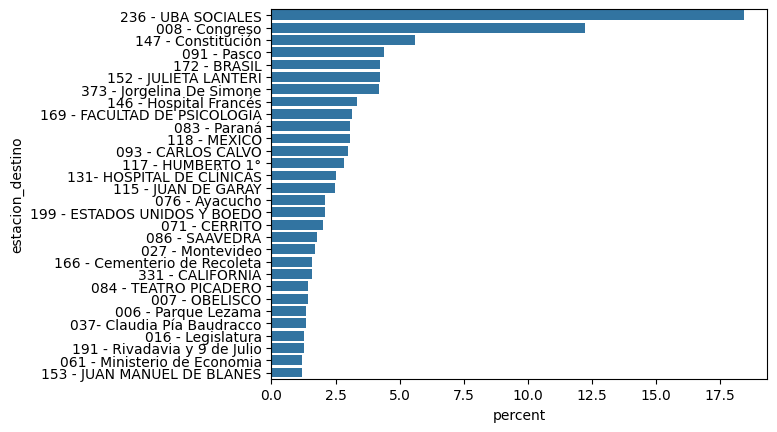

In [10]:
sns.countplot(df_top30, y="estacion_destino", order=top_30, stat='percent')

Para este trabajo nos enfocamos en predecir la estación de destino de los viajes que parten desde "236 - UBA SOCIALES". Analizamos la distribución de la variable estacion_destino y observamos que, si bien la mayoría de las clases presentan una distribución descendente relativamente uniforme, existen dos valores atípicos: la propia estación de origen (UBA SOCIALES) y la estación Congreso. Esto sugiere que hay una tendencia marcada a viajes cortos o circulares (mismo origen y destino), o a destinos cercanos y muy frecuentados.

Si bien el desbalance en este contexto no es estrictamente negativo —puede reflejar un uso intensivo del sistema en rutas populares—, a efectos analíticos decidimos eliminar la clase más frecuente (UBA SOCIALES) ya que no aporta información para la predicción (al ser igual al origen) y puede sesgar los resultados del modelo.

En etapas posteriores podríamos evaluar técnicas como submuestreo aleatorio de clases mayoritarias, o SMOTE para balancear las clases minoritarias, en caso de que el rendimiento del modelo lo requiera.

In [11]:
df = df[df['estacion_destino']!= '236 - UBA SOCIALES']

<Axes: xlabel='percent', ylabel='estacion_destino'>

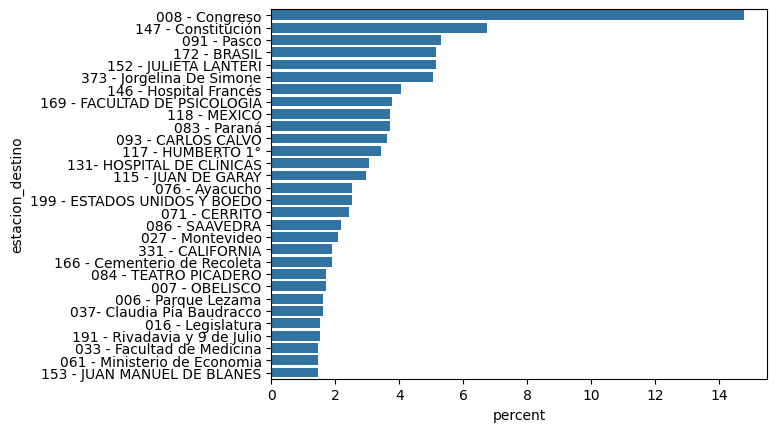

In [13]:
# Get the top 30 categories by count
top_30 = df['estacion_destino'].value_counts().nlargest(30).index

# Filter the DataFrame to only include these top 30 categories
df_top30 = df[df['estacion_destino'].isin(top_30)]
sns.countplot(df_top30, y="estacion_destino", order=top_30, stat='percent')


In [14]:
df

,duracion_estim_seg,modelo_bicicleta,estacion_destino,genero_usuario,edad_usuario,grupo_edad,day_of_year,week_key,week_of_year,day_of_week,...,quarter_key,quarter_of_year,day_of_quarter,quarter_desc_short,quarter_desc,ordinal_weekday_of_month,tavg,prcp,wspd,hora
622,832,FIT,131- HOSPITAL DE CLÍNICAS,MALE,31,26-35,292,202442,42,5,...,20244,4,18,Q4,Quarter 4,3,21.1,0.0,8.9,17
1721,926,FIT,064 - RIOBAMBA,None,<NA>,None,292,202442,42,5,...,20244,4,18,Q4,Quarter 4,3,21.1,0.0,8.9,13
1736,1736,FIT,286 - FILOSOFIA Y LETRAS,None,<NA>,None,292,202442,42,5,...,20244,4,18,Q4,Quarter 4,3,21.1,0.0,8.9,17
1948,816,ICONIC,041 - PARQUE PATRICIOS II,None,<NA>,None,292,202442,42,5,...,20244,4,18,Q4,Quarter 4,3,21.1,0.0,8.9,12
2536,592,ICONIC,084 - TEATRO PICADERO,MALE,29,26-35,291,202442,42,4,...,20244,4,17,Q4,Quarter 4,3,26.6,0.5,7.1,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495632,490,ICONIC,073 - Ruy Díaz de Guzmán,None,<NA>,None,299,202443,43,5,...,20244,4,25,Q4,Quarter 4,4,22.6,3.3,6.7,15
3500105,683,ICONIC,152 - JULIETA LANTERI,MALE,33,26-35,302,202444,44,1,...,20244,4,28,Q4,Quarter 4,4,24.4,0.0,8.2,8
3500462,821,FIT,179 - CASA SAN,MALE,19,19-25,300,202443,43,6,...,20244,4,26,Q4,Quarter 4,4,16.9,0.0,4.7,13
3500495,385,FIT,008 - Congreso,MALE,62,56-65,300,202443,43,6,...,20244,4,26,Q4,Quarter 4,4,16.9,0.0,4.7,19


Si bien identificamos un leve desbalance en la variable target estacion_destino, optamos por no aplicar técnicas de balanceo de clases (como undersampling o SMOTE) para el conjunto de entrenamiento principal.

La principal razón es que estas técnicas, si bien útiles en muchos escenarios, implican modificar la distribución natural de los datos, lo cual puede derivar en una pérdida significativa de información. En particular, el undersampling elimina ejemplos de clases mayoritarias —que en este caso son también estaciones altamente utilizadas— reduciendo así la capacidad del modelo de aprender patrones generalizables para los destinos más frecuentes.

Además, en nuestro caso, la cantidad total de clases (estaciones) es relativamente alta y su distribución, aunque desigual, no presenta un desbalance extremo. El uso de modelos robustos como Random Forest también mitiga parcialmente el impacto del desbalance, gracias a su capacidad de manejar datasets complejos y priorizar features informativas.

De todas formas, incluimos un ejemplo de aplicación de undersampling para mostrar cómo se vería un conjunto balanceado y permitir futuras comparaciones si se desea evaluar el impacto de esta transformación sobre el rendimiento del modelo.

In [15]:
X = df.drop(columns="estacion_destino").copy()
y = df["estacion_destino"].copy()

Index(['estacion_destino'], dtype='object')


<Axes: xlabel='percent', ylabel='estacion_destino'>

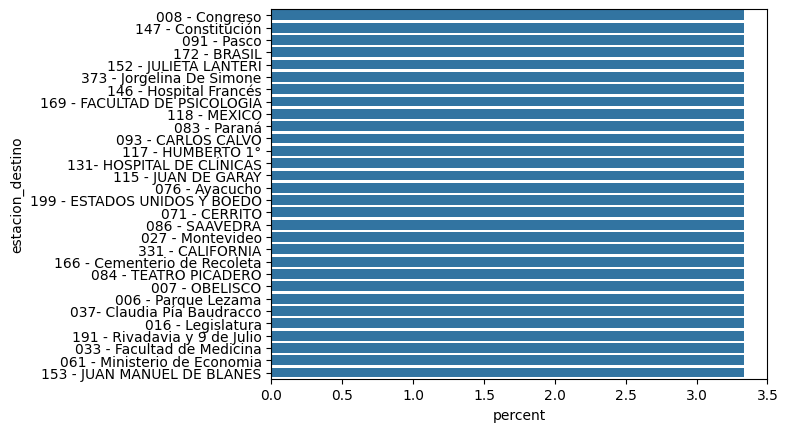

In [16]:
# Undersampling
undersample = RandomUnderSampler(random_state=42)
X_train_us, y_train_us = undersample.fit_resample(X, y)

# Get the top 20 categories by count
y_train_us = y_train_us.to_frame()
print(y_train_us.columns)

# Filter the DataFrame to only include these top 20 categories
y_train_us_top30 = y_train_us[y_train_us['estacion_destino'].isin(top_30)]
sns.countplot(y_train_us_top30, y="estacion_destino", order=top_30, stat='percent')

In [17]:
X_train_us

,duracion_estim_seg,modelo_bicicleta,genero_usuario,edad_usuario,grupo_edad,day_of_year,week_key,week_of_year,day_of_week,iso_day_of_week,...,quarter_key,quarter_of_year,day_of_quarter,quarter_desc_short,quarter_desc,ordinal_weekday_of_month,tavg,prcp,wspd,hora
109652,1229,FIT,None,<NA>,None,352,202451,51,2,2,...,20244,4,78,Q4,Quarter 4,3,23.3,9.9,9.3,18
2430537,965,ICONIC,None,<NA>,None,285,202441,41,5,5,...,20244,4,11,Q4,Quarter 4,2,22.3,0.0,6.6,21
2102863,497,ICONIC,None,<NA>,None,306,202444,44,5,5,...,20244,4,32,Q4,Quarter 4,1,25.9,0.0,11.7,16
332267,715,ICONIC,FEMALE,28,26-35,341,202449,49,5,5,...,20244,4,67,Q4,Quarter 4,1,23.7,14.0,9.6,21
1764362,1662,ICONIC,None,<NA>,None,320,202446,46,5,5,...,20244,4,46,Q4,Quarter 4,3,26.5,0.0,10.5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2458053,1827,FIT,FEMALE,19,19-25,282,202441,41,2,2,...,20244,4,8,Q4,Quarter 4,2,20.8,0.0,9.7,17
3380547,767,ICONIC,None,<NA>,None,290,202442,42,3,3,...,20244,4,16,Q4,Quarter 4,3,20.6,0.0,6.8,18
1963559,2084,FIT,None,<NA>,None,335,202448,48,6,6,...,20244,4,61,Q4,Quarter 4,5,21.7,0.0,8.9,16
1247498,1282,FIT,FEMALE,39,36-45,311,202445,45,3,3,...,20244,4,37,Q4,Quarter 4,1,21.7,0.0,11.3,22


Ahora vamos a empezar a realizar analisis entre varaibles:

/Users/dreitano/projects/maestria/proyectos_maestria/AnalisisDeDatos/TP2/.venv/lib/python3.13/site-packages/dython/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


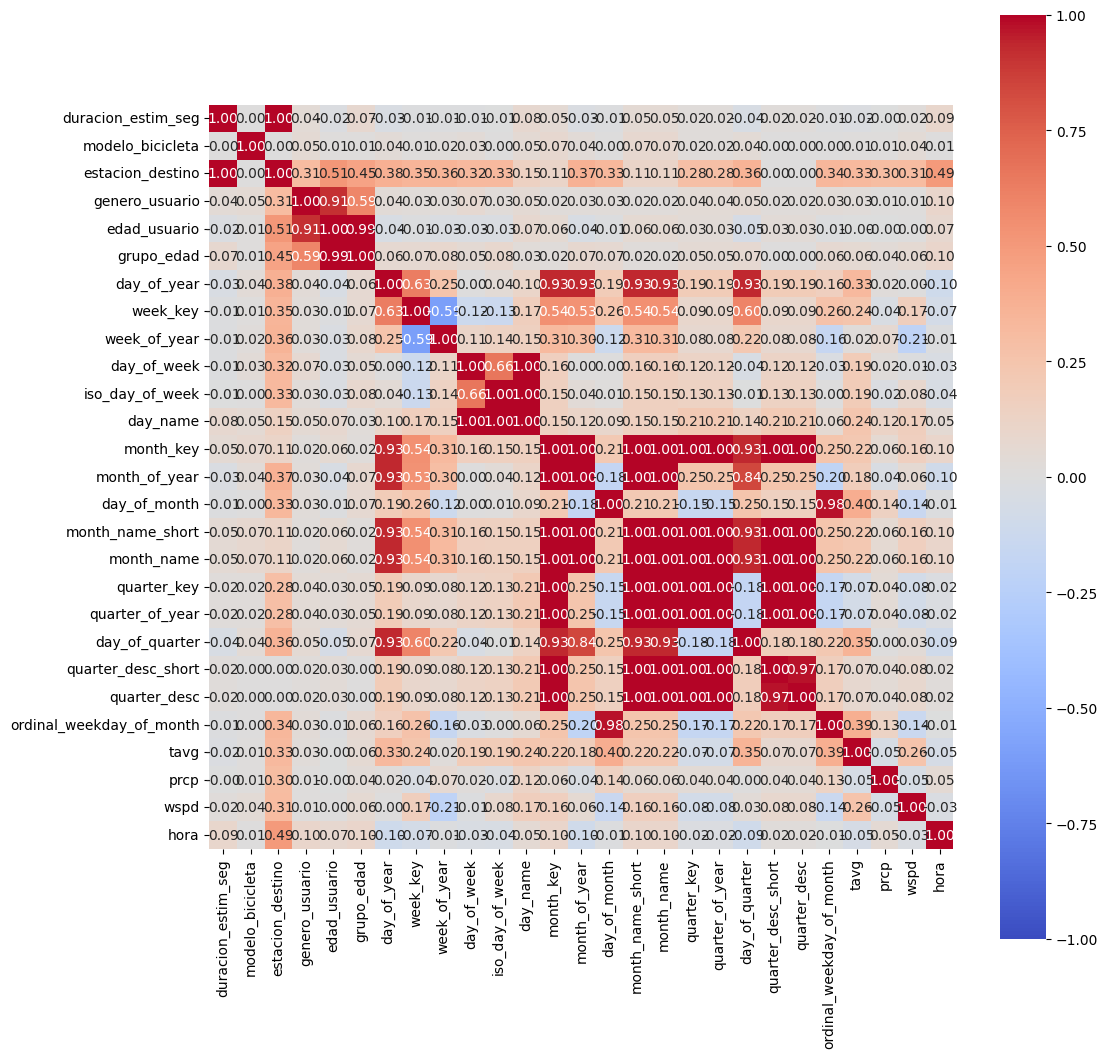

{'corr':                           duracion_estim_seg  modelo_bicicleta  \
 duracion_estim_seg                  1.000000          0.003785   
 modelo_bicicleta                    0.003785          1.000000   
 estacion_destino                    1.000000          0.000000   
 genero_usuario                      0.039695          0.048357   
 edad_usuario                       -0.019021          0.014442   
 grupo_edad                          0.072477          0.010850   
 day_of_year                        -0.031611          0.035063   
 week_key                           -0.014053          0.011370   
 week_of_year                       -0.014844          0.021965   
 day_of_week                        -0.011373          0.034329   
 iso_day_of_week                    -0.006308          0.004294   
 day_name                            0.077551          0.048858   
 month_key                           0.048141          0.072487   
 month_of_year                      -0.027483         

In [19]:
from dython.nominal import associations
import matplotlib.pyplot as plt
# Calcular asociaciones para todas las variables
associations(df, figsize=(12, 12), cmap='coolwarm')


Esta funcion nos permite ver una matriz de correlación tanto para variables numericas como categoricas. Esto nos ayuda a ver que las variables principales de análisis son:
"month_of_year", "day_of_month" , "iso_day_of_week", "estacion_destino", "grupo_edad", "tavg", "prcp", "wspd" y edad usuario.

Debido a la cantidad de falta de datos, eliminamos también la variable de edad usuario, grupo edad.


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1901 entries, 622 to 3500626
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   duracion_estim_seg        1901 non-null   int64  
 1   modelo_bicicleta          1901 non-null   object 
 2   estacion_destino          1901 non-null   object 
 3   genero_usuario            805 non-null    object 
 4   edad_usuario              805 non-null    Int64  
 5   grupo_edad                805 non-null    object 
 6   day_of_year               1901 non-null   int64  
 7   week_key                  1901 non-null   int64  
 8   week_of_year              1901 non-null   int64  
 9   day_of_week               1901 non-null   int64  
 10  iso_day_of_week           1901 non-null   int64  
 11  day_name                  1901 non-null   object 
 12  month_key                 1901 non-null   object 
 13  month_of_year             1901 non-null   int64  
 14  day_of_m

In [21]:
df = df[["month_of_year", "day_of_month" , "iso_day_of_week", "estacion_destino","hora", "tavg", "prcp", "wspd"]].copy()
df["prcp"] = df["prcp"].fillna(0)
df

,month_of_year,day_of_month,iso_day_of_week,estacion_destino,hora,tavg,prcp,wspd
622,10,18,5,131- HOSPITAL DE CLÍNICAS,17,21.1,0.0,8.9
1721,10,18,5,064 - RIOBAMBA,13,21.1,0.0,8.9
1736,10,18,5,286 - FILOSOFIA Y LETRAS,17,21.1,0.0,8.9
1948,10,18,5,041 - PARQUE PATRICIOS II,12,21.1,0.0,8.9
2536,10,17,4,084 - TEATRO PICADERO,18,26.6,0.5,7.1
...,...,...,...,...,...,...,...,...
3495632,10,25,5,073 - Ruy Díaz de Guzmán,15,22.6,3.3,6.7
3500105,10,28,1,152 - JULIETA LANTERI,8,24.4,0.0,8.2
3500462,10,26,6,179 - CASA SAN,13,16.9,0.0,4.7
3500495,10,26,6,008 - Congreso,19,16.9,0.0,4.7


Ademas de ello, vamos a generar un indice que combine todas las métricas climaticas, para evaluar su desempeño:

<Axes: xlabel='tavg', ylabel='Count'>

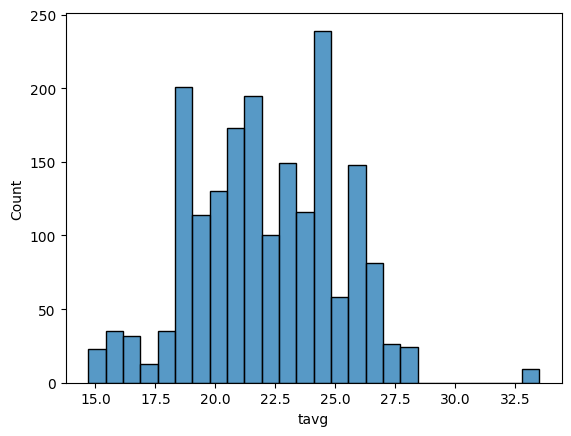

In [22]:
sns.histplot(df, x="tavg")

standart scaler

<Axes: xlabel='wspd', ylabel='Count'>

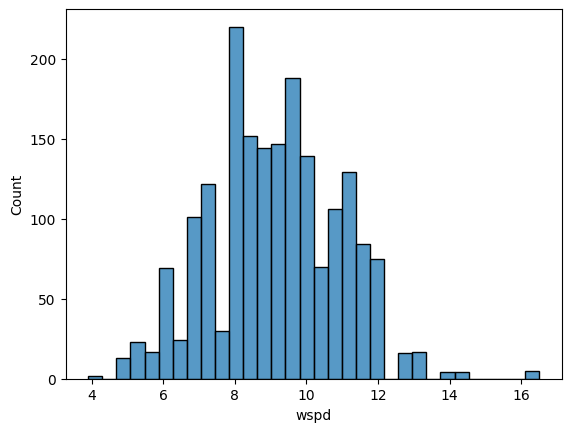

In [23]:
sns.histplot(df, x="wspd")

esta la escalamos con standart scaler

<Axes: xlabel='prcp', ylabel='Count'>

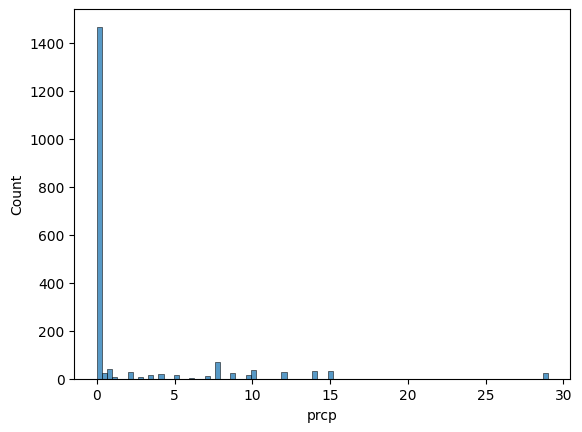

In [24]:
sns.histplot(df, x="prcp")

Esta la escalamos con normalizacion min max

In [25]:
df['norm_temp'] = (df['tavg'] - 10) / (25 - 10)  # 10°C (cold) to 25°C (ideal)
df['norm_precip'] = 1 - (df['prcp'] / 10).clip(0, 1)  # 0mm (ideal) to 10mm+ (bad)
df['norm_wind'] = 1 - (df['wspd'] / 30).clip(0, 1)  # 0km/h (ideal) to 30km/h+ (bad)

df['cycling_score'] = (
    0.5 * df['norm_temp'] +
    0.3 * df['norm_precip'] +
    0.2 * df['norm_wind']
)

Generamos indicador de fin de semana:

In [26]:
df["is_weekend"] = df["iso_day_of_week"].isin([6,7])

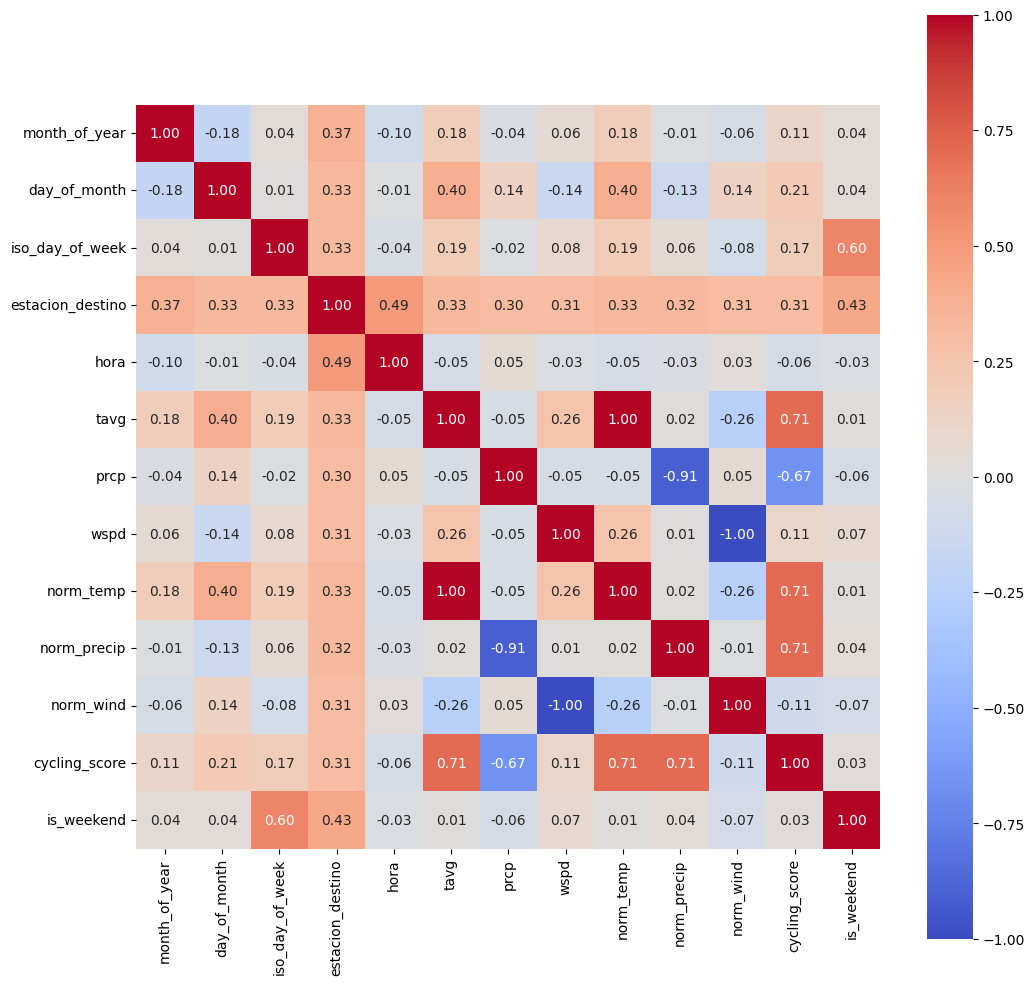

{'corr':                   month_of_year  day_of_month  iso_day_of_week  \
 month_of_year          1.000000     -0.179600         0.035839   
 day_of_month          -0.179600      1.000000         0.014139   
 iso_day_of_week        0.035839      0.014139         1.000000   
 estacion_destino       0.371989      0.331626         0.327688   
 hora                  -0.098807     -0.009005        -0.039440   
 tavg                   0.179088      0.395787         0.189994   
 prcp                  -0.035084      0.142055        -0.018170   
 wspd                   0.056550     -0.142665         0.084024   
 norm_temp              0.179088      0.395787         0.189994   
 norm_precip           -0.014882     -0.128056         0.062138   
 norm_wind             -0.056550      0.142665        -0.084024   
 cycling_score          0.113809      0.208351         0.173159   
 is_weekend             0.041530      0.037508         0.600731   
 
                   estacion_destino      hora      t

In [27]:
associations(df, figsize=(12, 12), cmap='coolwarm')

Con esto, vemos que podemos eliminar algunas de las variables:
- tavg: la eliminamos en base a la temperatura normalizada
- prcp . idem
- wspd: idem

In [28]:
X = df.drop(columns="estacion_destino").copy()
y = df["estacion_destino"].copy()

In [29]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

def sin_transformer(period):
    return FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi))

Realizamos un análisis exploratorio para identificar las variables más relevantes para la predicción de la estación de destino. Utilizamos una combinación de:

- matriz de correlación de Pearson para variables numéricas,

- matriz de asociación de Dython para variables categóricas o mixtas.

A partir de esto, identificamos como variables informativas:

- temporales: month_of_year, day_of_month, iso_day_of_week, hora

- climáticas: tavg, prcp, wspd

Otras variables como grupo_edad o edad_usuario fueron descartadas debido a un alto porcentaje de valores faltantes y baja correlación con la variable objetivo. De forma similar, modelo_bicicleta mostró poca variación y baja capacidad predictiva.

Adicionalmente, para mejorar la capacidad del modelo de captar el impacto del clima sobre la movilidad, creamos un nuevo feature compuesto denominado cycling_score, que combina temperatura, precipitaciones y velocidad del viento en un único valor estandarizado entre 0 y 1. Asignamos pesos heurísticos a cada componente:

- 50% temperatura normalizada (ideal: 25 °C)

- 30% precipitación (ideal: 0 mm)

- 20% viento (ideal: sin viento)

Este índice permite reflejar condiciones meteorológicas más favorables o desfavorables para usar bicicletas, y puede aportar una señal más robusta al modelo respecto a usar las variables crudas.

Finalmente, aplicamos técnicas de escalado:

- StandardScaler para tavg, wspd

- MinMaxScaler para prcp, debido a su distribución fuertemente sesgada

Esto asegura que todas las variables numéricas estén en escalas compatibles y facilita el entrenamiento de modelos que dependen de distancias o pesos relativos.

En base al análisis de correlación y asociación, observamos que algunas variables climáticas (tavg, prcp, wspd) estaban fuertemente correlacionadas con sus versiones normalizadas (norm_temp, norm_precip, norm_wind) y con el índice sintético cycling_score. Dado que este índice combina las tres dimensiones del clima en una única variable interpretable, decidimos eliminar las versiones originales (tavg, prcp, wspd) para reducir la dimensionalidad sin pérdida significativa de información.

Además, generamos la variable booleana is_weekend, que indica si el viaje se realizó un sábado o domingo, ya que este tipo de información puede capturar variaciones de comportamiento en los usuarios según el día de la semana.

# Normalizamos

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)
X_train.columns

Index(['month_of_year', 'day_of_month', 'iso_day_of_week', 'hora', 'tavg',
       'prcp', 'wspd', 'norm_temp', 'norm_precip', 'norm_wind',
       'cycling_score', 'is_weekend'],
      dtype='object')

In [31]:
# Assuming you have these periods for cyclical features
DAY_OF_MONTH_PERIOD = 31
DAY_OF_WEEK_PERIOD = 7
HOUR_PERIOD = 24


def sin_transformer(period, col_name):
    transformer = FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi))
    # Añadimos nombres de columnas manualmente
    transformer.get_feature_names_out = lambda input_features: [f"{col_name}_sin"]
    return transformer

def cos_transformer(period, col_name):
    transformer = FunctionTransformer(lambda x: np.cos(x / period * 2 * np.pi))
    transformer.get_feature_names_out = lambda input_features: [f"{col_name}_cos"]
    return transformer

# Create the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        # One-hot encode month_of_year
        ('month_onehot', OneHotEncoder(), ['month_of_year']),
        
        # Transformaciones cíclicas (con nombres personalizados)
        ('day_of_month_sin', sin_transformer(31, "day_of_month"), ['day_of_month']),
        ('day_of_month_cos', cos_transformer(31, "day_of_month"), ['day_of_month']),
        
        ('day_of_week_sin', sin_transformer(7, "day_of_week"), ['iso_day_of_week']),
        ('day_of_week_cos', cos_transformer(7, "day_of_week"), ['iso_day_of_week']),
        
        ('hour_sin', sin_transformer(24, "hour"), ['hora']),
        ('hour_cos', cos_transformer(24, "hour"), ['hora']),
        
        # Standard scaling for tavg and wspd
        ('standard_scaler', StandardScaler(), ['tavg', 'wspd']),
        
        # MinMax scaling for prcp
        ('minmax_scaler', MinMaxScaler(), ['prcp'])
    ],
    remainder='drop'  # This will drop any columns not specified
)

# Create the full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor)
])


In [32]:
X_train["month_of_year"].unique()

array([12, 10, 11,  9])

In [33]:
pipeline.fit(X_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('month_onehot',
                                                  OneHotEncoder(),
                                                  ['month_of_year']),
                                                 ('day_of_month_sin',
                                                  FunctionTransformer(func=<function sin_transformer.<locals>.<lambda> at 0x12f88f6a0>),
                                                  ['day_of_month']),
                                                 ('day_of_month_cos',
                                                  FunctionTransformer(func=<function cos_transformer.<locals>.<lambda> at 0x12f88f920>),
                                                  ['day_of_mo...
                                                  FunctionTransformer(func=<function cos_transformer.<locals>.<lambda> at 0x12f88f420>),
                                                  ['iso_day_of_week']),
                                                 ('hour_sin',
                                                  FunctionTransformer(func=<function sin_transformer.<locals>.<lambda> at 0x12f88fce0>),
                                                  ['hora']),
                                                 ('hour_cos',
                                                  FunctionTransformer(func=<function cos_transformer.<locals>.<lambda> at 0x12f88fe20>),
                                                  ['hora']),
                                                 ('standard_scaler',
                                                  StandardScaler(),
                                                  ['tavg', 'wspd']),
                                                 ('minmax_scaler',
                                                  MinMaxScaler(),
                                                  ['prcp'])]))])

In [34]:
X_train_transformed = pipeline.transform(X_train)
X_test_transformed = pipeline.transform(X_test)

In [35]:
X_train_transformed

array([[ 0.        ,  0.        ,  0.        , ...,  0.27881418,
        -1.01899347,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.5449538 ,
         0.25879615,  0.48275862],
       [ 0.        ,  1.        ,  0.        , ...,  0.17901182,
        -1.35232989,  0.1137931 ],
       ...,
       [ 0.        ,  0.        ,  1.        , ..., -0.45306978,
         1.64769791,  0.00689655],
       [ 0.        ,  1.        ,  0.        , ...,  1.14376796,
         0.64768864,  0.        ],
       [ 0.        ,  0.        ,  0.        , ..., -2.11644242,
        -1.29677382,  0.        ]], shape=(1273, 13))

In [36]:
def get_feature_names(column_transformer):
    # lista de nombres resultantes
    output_features = []
    
    for name, transformer, columns in column_transformer.transformers_:
        if transformer == 'drop':
            continue
        if transformer == 'passthrough':
            # columnas que pasan sin transformar
            if isinstance(columns, slice):
                # si es slice, obtén nombres desde input_features
                feature_names = column_transformer.feature_names_in_[columns]
            elif isinstance(columns, list):
                feature_names = columns
            else:
                feature_names = [columns]
            output_features.extend(feature_names)
            continue

        # Si el transformer tiene get_feature_names_out(), úsalo
        if hasattr(transformer, 'get_feature_names_out'):
            if isinstance(columns, list):
                names = transformer.get_feature_names_out(columns)
            else:
                names = transformer.get_feature_names_out()
            output_features.extend(names)
        else:
            # Para transformers que no tienen get_feature_names_out, poner nombres manuales
            # Por ejemplo, si sabes que genera 1 columna:
            if hasattr(transformer, 'n_features_out_'):
                n = transformer.n_features_out_
            else:
                # valor por defecto (1)
                n = 1
            # Crear nombres genéricos
            names = [f"{name}__{i}" for i in range(n)]
            output_features.extend(names)

    return output_features

# Luego:
feature_names = get_feature_names(pipeline.named_steps['preprocessor'])
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names)


In [37]:
X_train_transformed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1273 entries, 0 to 1272
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month_of_year_9      1273 non-null   float64
 1   month_of_year_10     1273 non-null   float64
 2   month_of_year_11     1273 non-null   float64
 3   month_of_year_12     1273 non-null   float64
 4   day_of_month_sin__0  1273 non-null   float64
 5   day_of_month_cos__0  1273 non-null   float64
 6   day_of_week_sin__0   1273 non-null   float64
 7   day_of_week_cos__0   1273 non-null   float64
 8   hour_sin__0          1273 non-null   float64
 9   hour_cos__0          1273 non-null   float64
 10  tavg                 1273 non-null   float64
 11  wspd                 1273 non-null   float64
 12  prcp                 1273 non-null   float64
dtypes: float64(13)
memory usage: 129.4 KB


In [38]:
y_train.unique()

array(['373 - Jorgelina De Simone', '008 - Congreso', '091 - Pasco',
       '169 - FACULTAD DE PSICOLOGIA', '147 - Constitución', '013 - ONCE',
       '082 - HOSPITAL ITALIANO', '107 - HOSPITAL GARRAHAN',
       '172 - BRASIL', '150 - RODRIGO BUENO', '046 - Chile',
       '027 - Montevideo', '146 - Hospital Francés', '086 - SAAVEDRA',
       '331 - CALIFORNIA', '117 - HUMBERTO 1°', '084 - TEATRO PICADERO',
       '183 - VIRREY CEVALLOS', '080 - VALLE', '006 - Parque Lezama',
       '153 - JUAN MANUEL DE BLANES', '038 - Plaza Libertad',
       '061 - Ministerio de Economia', '076 - Ayacucho',
       '272 - Plaza Bruno Giordano', '041 - PARQUE PATRICIOS II',
       '164 - FACULTAD DE INGENIERIA', '152 - JULIETA LANTERI',
       '073 - Ruy Díaz de Guzmán', '007 - OBELISCO',
       '199 - ESTADOS UNIDOS Y BOEDO', '184 - Pedro Echague',
       '273 - Plazoleta Colombia', '069 - Ecuador',
       '340 - PLAZA NUEVA POMPEYA', '144 - PUEYRREDÓN',
       '120 - HOSPITAL RAMOS MEJIA', '063 - Reco

Para preparar las variables numéricas y categóricas de manera apropiada para el entrenamiento del modelo, implementamos una pipeline de preprocesamiento que incluye codificación, normalización y transformación cíclica.

En primer lugar, utilizamos OneHotEncoder sobre la variable month_of_year para representar correctamente su naturaleza categórica discreta, y evitar interpretaciones ordinales por parte del modelo.

Luego, transformamos las variables cíclicas day_of_month, iso_day_of_week y hora mediante funciones seno y coseno, empleando FunctionTransformer con personalización de períodos. Esto permite representar la continuidad cíclica de estas variables (por ejemplo, que el día 31 esté cerca del día 1, o la hora 23 cerca de la 0), lo cual mejora la capacidad de generalización del modelo, especialmente en modelos basados en distancia o relaciones geométricas.

Finalmente, aplicamos técnicas de escalado:

StandardScaler sobre variables numéricas continuas (tavg, wspd) para centrar y reducir.

MinMaxScaler sobre prcp, ya que su distribución es altamente sesgada y centrada en valores bajos.

Todo este proceso fue encapsulado dentro de una pipeline de scikit-learn, asegurando la replicabilidad y evitando data leakage entre los conjuntos de entrenamiento y test.

In [42]:
from sklearn.decomposition import PCA
features = X_train_transformed_df.columns

pca = PCA(n_components=8)
X_pca = pca.fit_transform(X_train_transformed_df)

labels = y_train.copy()

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8'])
pca_df['label'] = labels

/var/folders/ml/gmqmyfhd39bc7mggbpwznw0r0000gn/T/ipykernel_6393/1128596543.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=pca_df, x='PC1', y='PC2', palette='viridis', s=60, alpha=0.7)
/var/folders/ml/gmqmyfhd39bc7mggbpwznw0r0000gn/T/ipykernel_6393/1128596543.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Etiqueta')


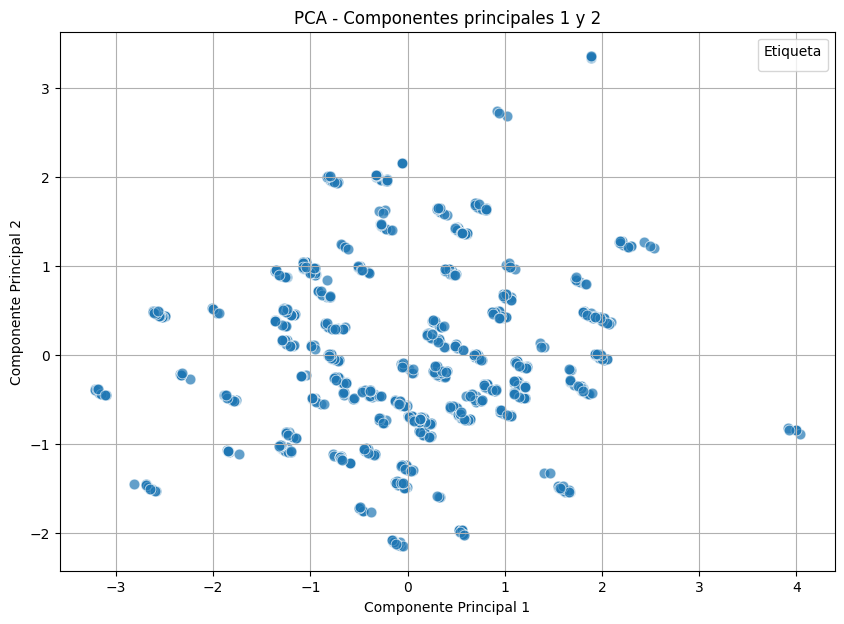

In [46]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', palette='viridis', s=60, alpha=0.7)
plt.title('PCA - Componentes principales 1 y 2')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Etiqueta')
plt.grid(True)
plt.show()

In [45]:
print(X_pca[0].min())
print(X_pca[0].max())

print(X_pca[1].min())
print(X_pca[1].max())

print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

-1.4286220811154244
0.8854614455838912
-1.0077831500246084
1.359056582990899
[0.23787088 0.16149249 0.10660302 0.10415991 0.09074816 0.07610206
 0.06517457 0.05716795]
0.8993190439194163


/Users/dreitano/projects/maestria/proyectos_maestria/AnalisisDeDatos/TP2/.venv/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


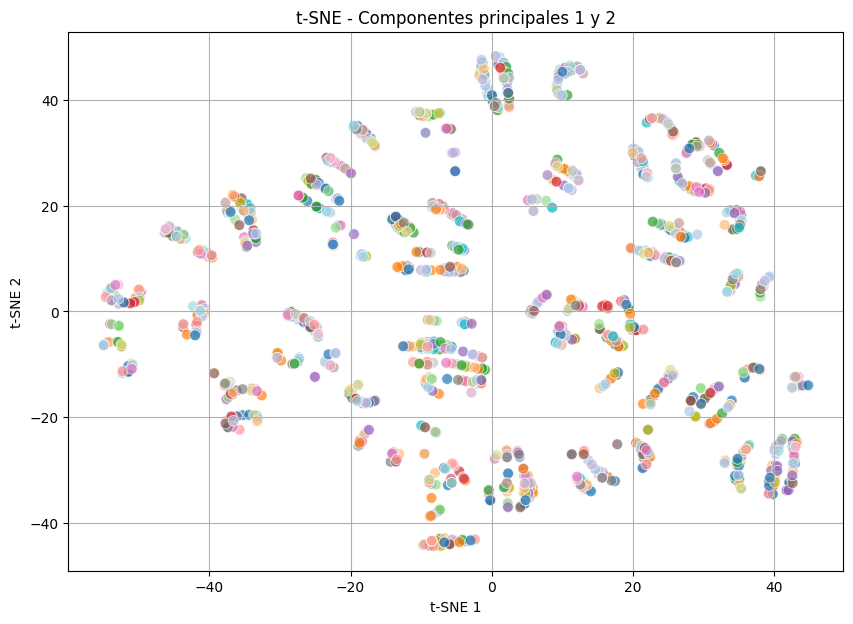

In [48]:
from sklearn.manifold import TSNE

# Apply t-SNE to the training set (using the same features as PCA)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_train_transformed_df)

# Create a DataFrame for visualization
tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['label'] = y_train.values

plt.figure(figsize=(10,7))
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='label', palette='tab20', legend=False, s=60, alpha=0.7)
plt.title('t-SNE - Componentes principales 1 y 2')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True)
plt.show()

Para evaluar la redundancia y relevancia de nuestras features, aplicamos dos técnicas de reducción de dimensionalidad: PCA (análisis de componentes principales) y t-SNE (técnica de embebido no lineal).

Con PCA, proyectamos el espacio original de características transformadas a un nuevo subespacio ortogonal. Los primeros 8 componentes principales explican aproximadamente el 90% de la varianza acumulada, lo cual indica que gran parte de la información contenida en el dataset puede conservarse con una representación de menor dimensión. Esto es útil para simplificar el modelo, mejorar el rendimiento computacional y reducir ruido.

A modo complementario, aplicamos t-SNE para explorar la estructura de los datos en un espacio bidimensional. A diferencia de PCA, t-SNE no busca conservar la varianza total sino preservar las relaciones locales entre puntos, lo que la hace muy útil para visualizar agrupamientos o separabilidad entre clases en tareas de clasificación multiclase.

Observamos que ambas técnicas muestran patrones distintos:

PCA permite cuantificar cuánta información se retiene al reducir la dimensionalidad y puede utilizarse como paso previo al modelado.

t-SNE, en cambio, es más adecuado para visualización e interpretación cualitativa de la estructura del dataset, pero no debe usarse como input directo en modelos predictivos.

En resumen, la reducción de dimensionalidad nos permitió validar que existe redundancia en el conjunto de features y que puede ser ventajoso trabajar en un subespacio reducido para ciertas tareas (como clustering, visualización o incluso entrenamiento si se desea robustecer modelos lineales o evitar overfitting).

## Conclusiones

En este trabajo práctico abordamos el ciclo completo de preparación de datos para el entrenamiento de un modelo de inteligencia artificial orientado a predecir la estación de destino de un viaje en bicicleta pública en la ciudad de Buenos Aires.

Comenzamos analizando la distribución de clases de la variable objetivo (estacion_destino) y tomamos decisiones fundamentadas para manejar su desbalance, excluyendo la clase mayoritaria irrelevante (UBA SOCIALES como destino).

A través del análisis exploratorio y estadístico, seleccionamos un subconjunto significativo de variables predictoras y descartamos aquellas con alta proporción de valores nulos o baja correlación con la variable objetivo. Complementamos este proceso con la creación de nuevas features derivadas (como cycling_score e indicadores de fin de semana) que capturan relaciones complejas en forma más condensada.

Aplicamos técnicas de transformación para adaptar las variables al modelo, incluyendo escalado, codificación y manejo de variables cíclicas mediante funciones trigonométricas. Esto mejora la capacidad del modelo para aprender patrones periódicos y evita interpretaciones erróneas.

Finalmente, la aplicación de PCA y t-SNE permitió validar la existencia de redundancia en el conjunto de features y facilitar la visualización e interpretación del espacio de datos. La retención del 90% de la varianza con solo 8 componentes principales refuerza la eficiencia del preprocesamiento realizado.

En conclusión, el dataset quedó correctamente preparado para ser utilizado en modelos predictivos, con un buen equilibrio entre información, dimensionalidad y robustez. Las decisiones tomadas en cada etapa fueron guiadas por fundamentos estadísticos y buenas prácticas de ingeniería de datos.